# Transcript Intelligence Pipeline

A comprehensive analysis of ~100 AegisCloud meeting transcripts to extract actionable business intelligence for multiple stakeholder groups.

This notebook processes meeting data through topic categorization, sentiment analysis, churn risk detection, feature gap aggregation, incident pattern analysis, and support issue categorization — all without external API dependencies.

## 1. Environment Setup & Imports

We begin by configuring the Python environment and importing all required modules from the `src/` package. The pipeline uses:
- **pandas** for data wrangling
- **VADER** for sentiment analysis (no API keys needed)
- **scikit-learn** for TF-IDF validation of topic assignments
- **matplotlib + seaborn** for publication-ready visualizations

In [1]:
import sys
import os
import logging
import warnings

# Ensure src/ is importable
sys.path.insert(0, '.')

# Suppress non-critical warnings for cleaner output
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

# Configure logging
logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')
logger = logging.getLogger(__name__)

# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

# Display settings
pd.set_option('display.max_colwidth', 100)
pd.set_option('display.max_rows', 50)
pd.set_option('display.max_columns', 20)

# Import pipeline modules
from src.data_loader import load_dataset, classify_call_type
from src.topic_categorizer import categorize_topics, get_topic_distribution
from src.sentiment_analyzer import analyze_sentiment, compute_sentence_sentiment
from src.insight_generator import (
    detect_churn_risk,
    aggregate_feature_gaps,
    analyze_incidents,
    categorize_support_issues,
)
from src.visualization_engine import create_all_visualizations, export_figures, setup_style

# Print environment info
print(f"Python version: {sys.version}")
print(f"pandas version: {pd.__version__}")
print(f"numpy version: {np.__version__}")
print(f"matplotlib version: {plt.matplotlib.__version__}")
print(f"seaborn version: {sns.__version__}")
print("\nAll modules imported successfully. Pipeline ready.")

Python version: 3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 11:23:37) [Clang 14.0.6 ]
pandas version: 2.3.2
numpy version: 2.1.3
matplotlib version: 3.10.0
seaborn version: 0.13.2

All modules imported successfully. Pipeline ready.


## 2. Data Loading & Call Type Classification

The data loader parses all meeting folders from the `dataset/` directory. Each folder contains up to 6 JSON files (meeting-info, transcript, summary, events, speakers, speaker-meta). Meetings are classified into three call types:

- **Internal**: All participants have @aegiscloud.com emails
- **Support**: Title matches "Support Case #XXXX" pattern
- **External**: Mix of internal and external email domains

In [2]:
print("Loading dataset...")
data = load_dataset('dataset')

# Extract DataFrames
meetings_df = data['meetings']
transcripts_df = data['transcripts']
summaries_df = data['summaries']
key_moments_df = data['key_moments']
action_items_df = data['action_items']
events_df = data['events']
speakers_df = data['speakers']

# Summary statistics
print(f"\n{'='*60}")
print(f"DATASET SUMMARY")
print(f"{'='*60}")
print(f"Total meetings loaded: {len(meetings_df)}")
print(f"\nMeetings by call type:")
print(meetings_df['call_type'].value_counts().to_string())
print(f"\nDate range: {meetings_df['start_time'].min()} to {meetings_df['start_time'].max()}")
print(f"Total transcript sentences: {len(transcripts_df):,}")
print(f"Total key moments: {len(key_moments_df):,}")
print(f"Total action items: {len(action_items_df):,}")

INFO: Dataset loaded: 100 meetings from 100 folders (0 skipped)
INFO:   external: 43 meetings
INFO:   internal: 30 meetings
INFO:   support: 27 meetings


Loading dataset...

DATASET SUMMARY
Total meetings loaded: 100

Meetings by call type:
call_type
external    43
internal    30
support     27

Date range: 2026-02-03T10:00:00.000Z to 2026-04-28T12:45:00.000Z
Total transcript sentences: 4,313
Total key moments: 402
Total action items: 397


In [3]:
# Show a sample meeting record
print("\nSample meeting record:")
display(meetings_df.head(3))


Sample meeting record:


,meeting_id,title,organizer,start_time,end_time,duration,call_type,participant_count,external_domains
0,01KQ03B0303900521BB089CA,Detect Outage - Remediation Plan Review,megan.lawson@aegiscloud.com,2026-03-16T09:30:00.000Z,2026-03-16T10:05:12.000Z,35.2,internal,3,[]
1,01KQ0C1280EDA4E70AAD7C35,Support Case #9279 - Summit Trust Billing Inquiry,sarah.chen@aegiscloud.com,2026-02-06T09:15:00.000Z,2026-02-06T09:38:48.000Z,23.8,support,2,[summittrust.com]
2,01KQ0CAE7F064EC93F0540CA,Weekly Engineering Standup,chris.lee@aegiscloud.com,2026-02-16T10:00:00.000Z,2026-02-16T10:29:00.000Z,29.0,internal,4,[]


## 3. Exploratory Data Summary

Before diving into analysis, we examine the basic characteristics of the dataset: meeting durations, participant counts, temporal distribution, and speaker activity.

In [4]:
# Meeting duration statistics
print("Meeting Duration Statistics (minutes):")
print(meetings_df['duration'].describe().to_string())
print()

# Participant count distribution
print("\nParticipant Count Distribution:")
print(meetings_df['participant_count'].describe().to_string())
print()

# Date range and temporal distribution
if 'start_time' in meetings_df.columns:
    meetings_df['start_date'] = pd.to_datetime(meetings_df['start_time'], errors='coerce').dt.date
    print("\nMeetings per date (top 10 busiest days):")
    date_counts = meetings_df['start_date'].value_counts().head(10)
    print(date_counts.to_string())

# Top speakers by appearance count
if not transcripts_df.empty:
    print("\nTop 10 Speakers by Appearance Count:")
    speaker_counts = transcripts_df.groupby('speaker_name')['meeting_id'].nunique().sort_values(ascending=False).head(10)
    print(speaker_counts.to_string())

Meeting Duration Statistics (minutes):
count    100.000000
mean      30.309000
std       12.157503
min        9.300000
25%       20.850000
50%       29.600000
75%       40.325000
max       54.300000


Participant Count Distribution:
count    100.000000
mean       3.110000
std        0.941683
min        2.000000
25%        2.000000
50%        3.000000
75%        4.000000
max        5.000000


Meetings per date (top 10 busiest days):
start_date
2026-03-14    3
2026-04-22    3
2026-03-12    3
2026-03-16    2
2026-04-17    2
2026-04-24    2
2026-04-03    2
2026-03-11    2
2026-04-07    2
2026-04-01    2

Top 10 Speakers by Appearance Count:
speaker_name
Ananya Sharma       14
Maria Santos        13
Kevin O'Brien       13
Sofia Petrov        12
Sarah Chen          11
Nina Kowalski       11
Mike Romano         11
Tyler Washington    10
Ravi Gupta          10
David Kim            9


## 4. Topic Categorization & Distribution

### Methodology

We use a **hybrid approach** for topic categorization:

1. **Primary (rule-based):** Keyword matching against meeting titles, summary text, and pre-existing topic arrays from summary.json. This is preferred because the domain taxonomy is well-defined and the dataset includes pre-labeled topics.

2. **Validation (TF-IDF + K-means):** Vectorizes transcript text and clusters meetings to verify that rule-based assignments align with natural text groupings.

3. **Fallback:** Maps pre-existing topics from summary.json to the taxonomy using fuzzy keyword overlap.

The topic taxonomy covers:
- **Product areas:** Detect, Comply, Identity
- **Operational themes:** Incident Response, Sprint Planning, Customer Success
- **Business themes:** Billing, Renewal, Competitive

In [5]:
print("Categorizing topics...")
topic_results = categorize_topics(meetings_df, summaries_df, transcripts_df)

print(f"\nTopic categorization complete: {len(topic_results)} meetings processed")
print(f"\nMethod distribution:")
print(topic_results['method'].value_counts().to_string())

# Get topic distribution
topic_distribution = get_topic_distribution(topic_results)
print(f"\nTopic Distribution Across Meetings:")
print("="*50)
display(topic_distribution)

INFO: Topic categorization complete: 100 meetings processed
INFO:   rule_based: 100 meetings


Categorizing topics...

Topic categorization complete: 100 meetings processed

Method distribution:
method
rule_based    100

Topic Distribution Across Meetings:


,topic,count,percentage
0,Comply,78,78.0
1,Detect,71,71.0
2,Incident Response,68,68.0
3,Renewal,44,44.0
4,Customer Success,39,39.0
5,Identity,35,35.0
6,Competitive,25,25.0
7,Billing,23,23.0
8,Sprint Planning,22,22.0


In [6]:
# Show example meetings for top 3 topics
top_topics = topic_distribution.head(3)['topic'].tolist()
print("\nExample meetings for top 3 topics:\n")

for topic in top_topics:
    print(f"--- {topic} ---")
    topic_meetings = topic_results[topic_results['primary_topic'] == topic].head(2)
    for _, row in topic_meetings.iterrows():
        meeting = meetings_df[meetings_df['meeting_id'] == row['meeting_id']]
        if not meeting.empty:
            print(f"  Title: {meeting.iloc[0]['title']}")
            print(f"  Confidence: {row['confidence']:.2f}, Method: {row['method']}")
    print()


Example meetings for top 3 topics:

--- Comply ---
  Title: Aegis / Redwood Clinical - ISO 27001 Preparation
  Confidence: 0.75, Method: rule_based
  Title: Comply v2 - Launch Readiness Review
  Confidence: 0.38, Method: rule_based

--- Detect ---
  Title: Weekly Engineering Standup
  Confidence: 0.44, Method: rule_based
  Title: SOC 2 Audit Preparation - Internal
  Confidence: 0.22, Method: rule_based

--- Incident Response ---
  Title: Detect Outage - Remediation Plan Review
  Confidence: 0.71, Method: rule_based
  Title: Aegis / Meridian Capital - Service Reliability Discussion
  Confidence: 0.57, Method: rule_based



## 5. Sentiment Analysis & Trends

### Methodology

We compute **VADER sentiment scores** for each transcript sentence, then aggregate per meeting weighted by sentence length. VADER is well-suited for short conversational text and requires no API keys.

The pipeline:
1. Computes per-sentence VADER compound scores
2. Aggregates per meeting (weighted by word count)
3. Normalizes VADER [-1, 1] to [1, 5] scale for comparison with pre-existing sentimentScore
4. Computes Pearson correlation between our scores and the pre-existing labels
5. Produces time-series trends by call type

In [7]:
print("Analyzing sentiment...")
sentiment_results = analyze_sentiment(transcripts_df, summaries_df, meetings_df)

meeting_sentiment = sentiment_results['meeting_sentiment']
call_type_stats = sentiment_results['call_type_stats']
time_series = sentiment_results['time_series']
correlation = sentiment_results['correlation']
trend_interpretation = sentiment_results['trend_interpretation']

print(f"\nSentiment analysis complete: {len(meeting_sentiment)} meetings analyzed")
print(f"\n{'='*60}")
print("CALL TYPE STATISTICS")
print(f"{'='*60}")
display(call_type_stats)

Analyzing sentiment...


INFO: Sentiment analysis complete: 100 meetings analyzed, correlation r=0.805 (p=0.0000)



Sentiment analysis complete: 100 meetings analyzed

CALL TYPE STATISTICS


,call_type,mean,median,std
0,internal,3.691807,3.684457,0.357036
1,support,3.694035,3.635220,0.284606
2,external,3.914406,3.968727,0.275100


In [8]:
# Correlation results
print(f"\n{'='*60}")
print("VADER vs. PRE-EXISTING SENTIMENT CORRELATION")
print(f"{'='*60}")
if correlation['pearson_r'] is not None:
    print(f"Pearson r: {correlation['pearson_r']:.4f}")
    print(f"p-value:   {correlation['p_value']:.6f}")
    if correlation['p_value'] < 0.05:
        print("=> Statistically significant correlation")
    else:
        print("=> Correlation not statistically significant")
else:
    print("Insufficient data for correlation analysis")


VADER vs. PRE-EXISTING SENTIMENT CORRELATION
Pearson r: 0.8051
p-value:   0.000000
=> Statistically significant correlation


### Trend Interpretation

The following summarizes how sentiment has evolved over the analysis period for each call type. Trends are identified by comparing the first half of the time period to the second half.

In [9]:
print(trend_interpretation)

Sentiment Trend Summary:
- External calls: Sentiment remained stable over the period. Average sentiment is generally positive (3.95/5.0).
- Internal calls: Sentiment remained stable over the period. Average sentiment is generally positive (3.75/5.0).
- Support calls: Sentiment improved (+0.14) over the period. Average sentiment is generally positive (3.74/5.0).


## 6. Churn Risk Detection (External Calls)

### Methodology

Churn risk is assessed for external accounts by analyzing:
- **Churn signal** key moments (weight: ×3)
- **Concern** key moments (weight: ×1)
- **Competitive mentions** (weight: ×2)
- **Negative sentiment penalty** (if avg sentiment < 2.5)

The composite score is normalized to a 0-10 scale.

### Interpretation for Sales Managers

Accounts with high risk scores should be prioritized for retention outreach. The evidence column provides specific moments from meetings that triggered the risk assessment, enabling targeted conversations.

In [10]:
print("Detecting churn risk in external accounts...")
churn_results = detect_churn_risk(meetings_df, key_moments_df, meeting_sentiment)

print(f"\nChurn risk analysis complete: {len(churn_results)} accounts assessed")
print(f"Accounts with non-zero risk: {len(churn_results[churn_results['risk_score'] > 0]) if not churn_results.empty else 0}")

# Display top 10 at-risk accounts
print(f"\n{'='*60}")
print("TOP 10 AT-RISK ACCOUNTS")
print(f"{'='*60}")
if not churn_results.empty:
    display(churn_results[['account_domain', 'risk_score', 'churn_signals_count', 'avg_sentiment']].head(10))
else:
    print("No churn risk data available.")

INFO: Churn risk analysis complete: 32 accounts assessed, 29 with non-zero risk


Detecting churn risk in external accounts...

Churn risk analysis complete: 32 accounts assessed
Accounts with non-zero risk: 29

TOP 10 AT-RISK ACCOUNTS


,account_domain,risk_score,churn_signals_count,avg_sentiment
0,brightpathcommerce.com,10.0,2,3.87
1,northstarpharma.com,10.0,3,3.50
2,cobaltsoftware.com,10.0,3,3.52
3,ironcladfinancial.com,9.0,2,3.67
4,novaretail.com,8.0,2,3.55
5,blackridgeinvest.com,7.0,1,3.91
6,summittrust.com,6.0,2,3.77
7,quantumedge.com,6.0,1,3.82
8,meridiancapital.com,6.0,1,3.33
9,redwoodclinical.com,5.0,1,4.01


In [11]:
# Show evidence for the highest-risk account
if not churn_results.empty and len(churn_results) > 0:
    top_account = churn_results.iloc[0]
    print(f"\nEvidence for highest-risk account: {top_account['account_domain']}")
    print(f"Risk Score: {top_account['risk_score']}")
    print(f"Churn Signals: {top_account['churn_signals_count']}")
    print(f"Avg Sentiment: {top_account['avg_sentiment']}")
    print(f"\nKey moments contributing to risk:")
    evidence = top_account.get('evidence', [])
    for i, ev in enumerate(evidence[:5], 1):
        if isinstance(ev, dict):
            print(f"  {i}. [{ev.get('type', '')}] {ev.get('text', '')[:100]}")
        else:
            print(f"  {i}. {str(ev)[:100]}")


Evidence for highest-risk account: brightpathcommerce.com
Risk Score: 10.0
Churn Signals: 2
Avg Sentiment: 3.87

Key moments contributing to risk:
  1. [churn_signal] Kendra reveals Brightpath has been conducting a six-week security vendor evaluation and is seriously
  2. [concern] Kendra describes the March six-hour threat monitoring outage and its impact on a 24/7 retail transac
  3. [concern] Kendra confirms spring peak season deadline in late March, creating urgency for the deployment timel
  4. [churn_signal] Kendra raises the December reliability incident she read about on community forums, introducing a po


## 7. Feature Gap Aggregation (All Call Types)

### Methodology

Feature gaps are extracted from `feature_gap` key moments across all meeting types. Each gap is:
1. Assigned a **product area** (Detect, Comply, Identity, Platform) via keyword matching
2. **Consolidated** with similar descriptions using fuzzy string matching
3. **Ranked** by frequency of mention across distinct meetings

### Interpretation for Product Managers

Feature gaps that appear across multiple meetings and stakeholder types represent the strongest signals for roadmap prioritization. The product area breakdown helps route gaps to the right team.

In [12]:
print("Aggregating feature gaps...")
feature_gap_results = aggregate_feature_gaps(key_moments_df, meetings_df)

print(f"\nFeature gap analysis complete: {len(feature_gap_results)} unique gaps identified")
if not feature_gap_results.empty:
    print(f"Total mentions: {feature_gap_results['mention_count'].sum()}")

# Display top feature gaps by frequency
print(f"\n{'='*60}")
print("TOP FEATURE GAPS BY FREQUENCY")
print(f"{'='*60}")
if not feature_gap_results.empty:
    display(feature_gap_results[['feature_description', 'product_area', 'mention_count']].head(10))
else:
    print("No feature gaps identified.")

Aggregating feature gaps...


INFO: Feature gap analysis complete: 51 unique gaps from 51 total mentions



Feature gap analysis complete: 51 unique gaps identified
Total mentions: 51

TOP FEATURE GAPS BY FREQUENCY


,feature_description,product_area,mention_count
0,Gregory requests proactive seat-count threshold alerts to avoid discovering overages on future i...,Detect,1
1,"Ravi raises alert fatigue as a risk, noting that unacknowledged alerts could raise red flags wit...",Detect,1
2,"Wayne asks about SOC 2 compliance reporting, signaling potential expansion opportunity with the ...",Comply,1
3,"Discussion of launching without HIPAA and ISO 27001 documentation on day one, which Megan flags ...",Comply,1
4,"Sarah confirms that granular file-level restore is not currently supported in Aegis Protect, val...",Platform,1
5,James reveals that on-demand reporting is not yet available but is coming in an upcoming release,Comply,1
6,"Julia challenges the platform's architecture, pointing out that a single component failure took ...",Detect,1
7,"Sofia flags a clear cluster of support tickets around JIT provisioning and SSO configuration, di...",Identity,1
8,"Julia reacts positively to the remediation guidance feature, noting her current process leaves g...",Comply,1
9,Sarah identifies the misconfigured generic S3 endpoint as a likely contributor to the 403 errors...,Platform,1


In [13]:
# Product area breakdown
if not feature_gap_results.empty:
    print("\nFeature Gaps by Product Area:")
    area_summary = feature_gap_results.groupby('product_area').agg(
        gap_count=('feature_description', 'count'),
        total_mentions=('mention_count', 'sum')
    ).sort_values('total_mentions', ascending=False)
    display(area_summary)


Feature Gaps by Product Area:


,gap_count,total_mentions
product_area,,
Comply,21,21
Detect,16,16
Platform,9,9
Identity,5,5


## 8. Incident Pattern Analysis (Internal Calls)

### Methodology

Incident patterns are extracted from internal meetings by:
1. Filtering for `technical_issue` key moments
2. Grouping by affected system/component via keyword extraction
3. Flagging **systemic issues** (same component in 3+ meetings)
4. Detecting **team health signals**: timeline risk, resource constraints, process gaps

### Interpretation for Engineering Leads

Systemic issues represent recurring problems that haven't been resolved. The team health indicators surface organizational risks that may not be visible in individual incident reports.

In [14]:
print("Analyzing incident patterns from internal meetings...")
incident_results = analyze_incidents(meetings_df, key_moments_df, action_items_df)

incidents_df = incident_results['incidents']
systemic_df = incident_results['systemic_issues']
timeline_df = incident_results['timeline']
team_health_df = incident_results['team_health']
action_items_by_owner = incident_results['action_items_by_owner']

print(f"\nIncident analysis complete:")
print(f"  Components with issues: {len(incidents_df)}")
print(f"  Systemic issues (3+ meetings): {len(systemic_df)}")
print(f"  Team health signals: {len(team_health_df)}")

# Display systemic issues
print(f"\n{'='*60}")
print("SYSTEMIC ISSUES (appearing in 3+ meetings)")
print(f"{'='*60}")
if not systemic_df.empty:
    display(systemic_df[['component', 'issue_count', 'meeting_count']])
else:
    print("No systemic issues detected.")

INFO: Incident analysis complete: 6 components, 3 systemic issues, 32 health signals


Analyzing incident patterns from internal meetings...

Incident analysis complete:
  Components with issues: 6
  Systemic issues (3+ meetings): 3
  Team health signals: 32

SYSTEMIC ISSUES (appearing in 3+ meetings)


,component,issue_count,meeting_count
0,detect,6,6
1,event_processing,7,7
2,other,5,5


In [15]:
# Incident timeline
print("\nIncident Discussion Timeline (recent):")
if not timeline_df.empty:
    display(timeline_df[['date', 'component', 'text']].tail(10))
else:
    print("No timeline data available.")

# Team health indicators
print(f"\nTeam Health Indicators:")
if not team_health_df.empty:
    print(f"  Timeline risk signals: {team_health_df['timeline_risk'].sum()}")
    print(f"  Resource constraint signals: {team_health_df['resource_constraints'].sum()}")
    print(f"  Process gap signals: {team_health_df['process_gaps'].sum()}")
else:
    print("  No team health signals detected.")


Incident Discussion Timeline (recent):


,date,component,text
12,2026-03-18 16:30:00+00:00,event_processing,Tom confirms customers had six hours of no threat monitoring alerts due to a single point of fai...
13,2026-03-28 16:00:00+00:00,other,Sofia identifies the IAM role hierarchy inheritance logic for nested conflicting role groups as ...
14,2026-04-01 17:45:00+00:00,detect,Ravi detailed the resilience architecture including redundant processing nodes and circuit break...
15,2026-04-10 11:30:00+00:00,infrastructure,Tom Bradley details the March outage root cause and confirms architectural remediation with redu...
16,2026-04-13 11:45:00+00:00,detect,Ananya details three distinct SCIM sync failure modes and notes the need for disciplined testing...
17,2026-04-15 16:45:00+00:00,other,Tyler reveals backup job queue times spiked to 47 minutes for a job that should complete in unde...
18,2026-04-17 17:15:00+00:00,comply,Sofia identifies a timeout bug in Comply v2 affecting enterprise customers with large tenant dat...
19,2026-04-20 09:30:00+00:00,detect,Nina flags that the uptime SLA documentation references 99.9% availability but Detect fell below...
20,2026-04-22 14:45:00+00:00,other,Brian notes ongoing ISO 27001 formatting issue where control numbering doesn't match customer ex...
21,2026-04-26 11:45:00+00:00,event_processing,Ravi explains the root cause of the March Detect outage: a single point of failure in the ingest...



Team Health Indicators:
  Timeline risk signals: 27
  Resource constraint signals: 3
  Process gap signals: 3


## 9. Support Issue Categorization (Support Calls)

### Methodology

Support meetings are analyzed by:
1. **Categorizing** each case by issue type (billing, technical, provisioning, compliance, access/permissions, performance) via keyword matching on title and summary
2. **Identifying high-frustration** cases where sentiment falls below threshold
3. **Detecting resolution patterns** through `positive_pivot` key moments
4. **Correlating** support cases with known incidents

### Interpretation for Support Leaders

The category distribution reveals where support effort is concentrated. High-frustration cases need immediate attention, while resolution patterns show what's working well.

In [16]:
print("Categorizing support issues...")
support_results = categorize_support_issues(meetings_df, summaries_df, key_moments_df)

issue_categories = support_results['issue_categories']
frustration_cases = support_results['frustration_cases']
resolution_patterns = support_results['resolution_patterns']
incident_correlation = support_results['incident_correlation']

print(f"\nSupport issue analysis complete:")
print(f"  Issue categories identified: {len(issue_categories)}")
print(f"  High-frustration cases: {len(frustration_cases)}")
print(f"  Resolution patterns (positive pivots): {len(resolution_patterns)}")

# Display issue category distribution
print(f"\n{'='*60}")
print("SUPPORT ISSUE CATEGORY DISTRIBUTION")
print(f"{'='*60}")
if not issue_categories.empty:
    display(issue_categories)
else:
    print("No support issue categories identified.")

INFO: Support issue analysis complete: 27 meetings categorized, 16 frustration cases, 15 resolutions


Categorizing support issues...

Support issue analysis complete:
  Issue categories identified: 7
  High-frustration cases: 16
  Resolution patterns (positive pivots): 15

SUPPORT ISSUE CATEGORY DISTRIBUTION


,category,count,percentage
0,technical,13,48.1
1,billing,4,14.8
2,compliance,3,11.1
3,provisioning,3,11.1
4,other,2,7.4
5,performance,1,3.7
6,access/permissions,1,3.7


In [17]:
# High-frustration cases
print("\nHigh-Frustration Cases:")
if not frustration_cases.empty:
    display(frustration_cases[['title', 'sentiment_score']].head(5))
else:
    print("No high-frustration cases detected.")

# Resolution patterns
print("\nResolution Patterns (Positive Pivots):")
if not resolution_patterns.empty:
    display(resolution_patterns[['title', 'pivot_text', 'speaker']].head(5))
else:
    print("No resolution patterns detected.")


High-Frustration Cases:


,title,sentiment_score
0,Support Case #3266 - Trailhead Marketplace Detect Alerts Not Firing,1.4
1,Support Case #6573 - Ridgeline Logistics Detect Data Gaps,2.1
2,Support Case #3677 - Coastal Living Co MFA Token Failures,2.2
3,Support Case #8749 - Coastal Living Co SAML Certificate Rotation Bug,2.2
4,Support Case #6635 - Nova Retail Group SSO Login Failures,2.3



Resolution Patterns (Positive Pivots):


,title,pivot_text,speaker
0,Support Case #9279 - Summit Trust Billing Inquiry,Gregory acknowledges partial responsibility for the oversight and shifts focus constructively to...,Gregory Fisk
1,Support Case #5889 - Ridgeline Logistics Detect Latency Issues,Paula acknowledges she likes the Detect product when it works and appreciates Priya's transparen...,Paula Schneider
2,Support Case #3296 - Pinnacle Insurance Comply v2 Report Formatting Issue,Marcus confirms the bug is reproducible on his end and acknowledges it is a rendering defect int...,Marcus Williams
3,Support Case #2638 - Pineridge Systems CloudPrime S3 Backup Connector,"Yuki recalls a routine CloudPrime policy review around the time failures began, providing a stro...",Yuki Tanaka
4,Support Case #1993 - Forge Industries Comply v2 Early Access Question,"Elena reveals Comply v2 GA launch is only four days away on April 7th, far sooner than the custo...",Elena Vasquez


## 10. Visualization Compilation

We now generate all 9 charts using a consistent visual style. These charts will be displayed inline and also exported as PNGs for the slide deck.

Generating visualizations...
Generated 9 charts:
  - topic_distribution
  - sentiment_time_series
  - sentiment_boxplot
  - sentiment_correlation
  - churn_risk_ranking
  - feature_gap_frequency
  - incident_timeline
  - support_categories
  - sentiment_shift


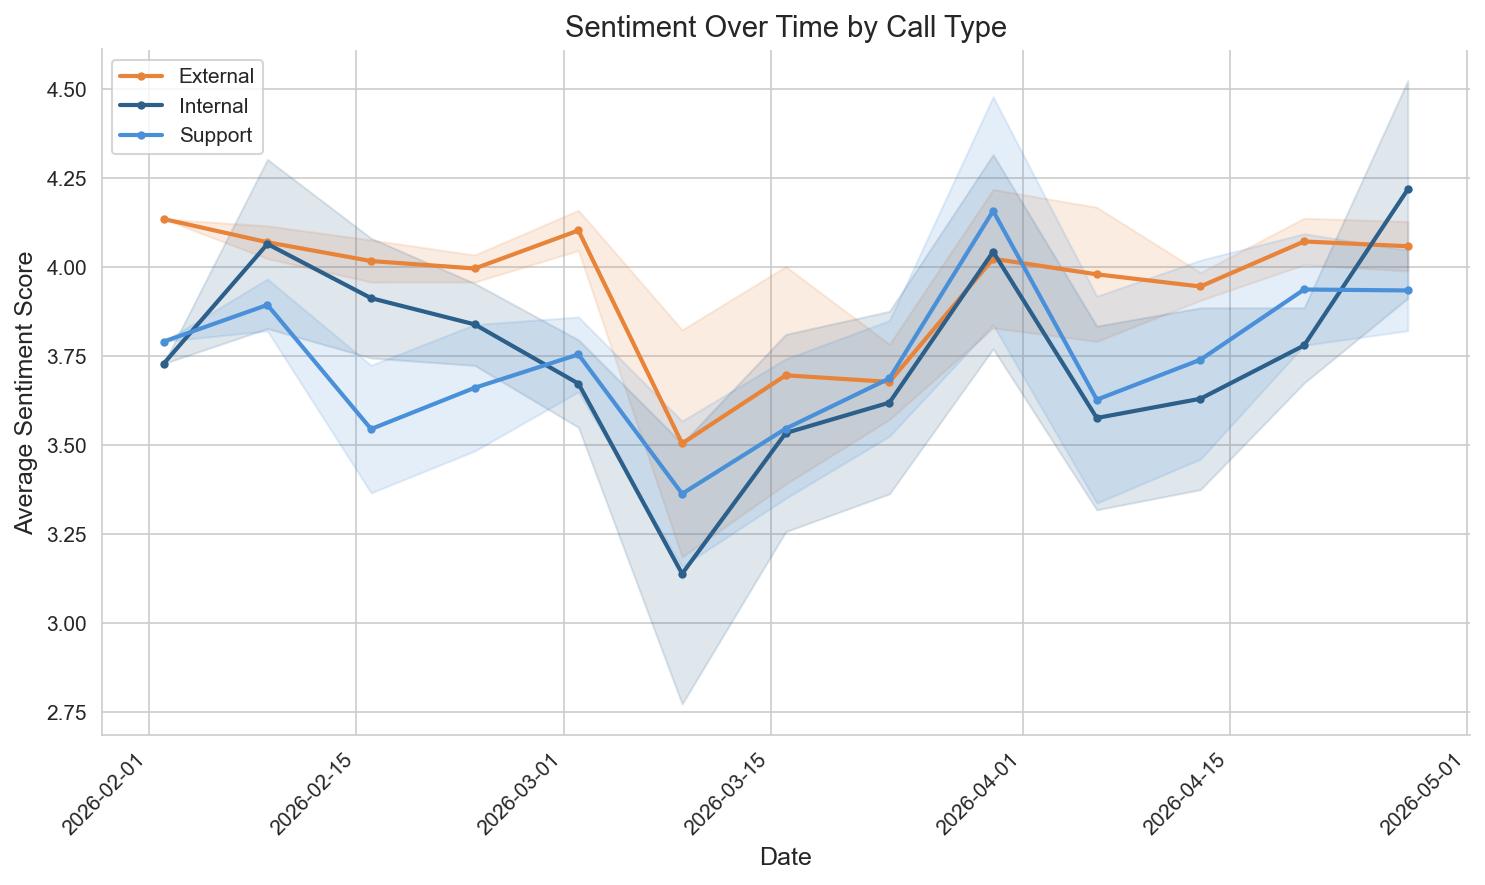

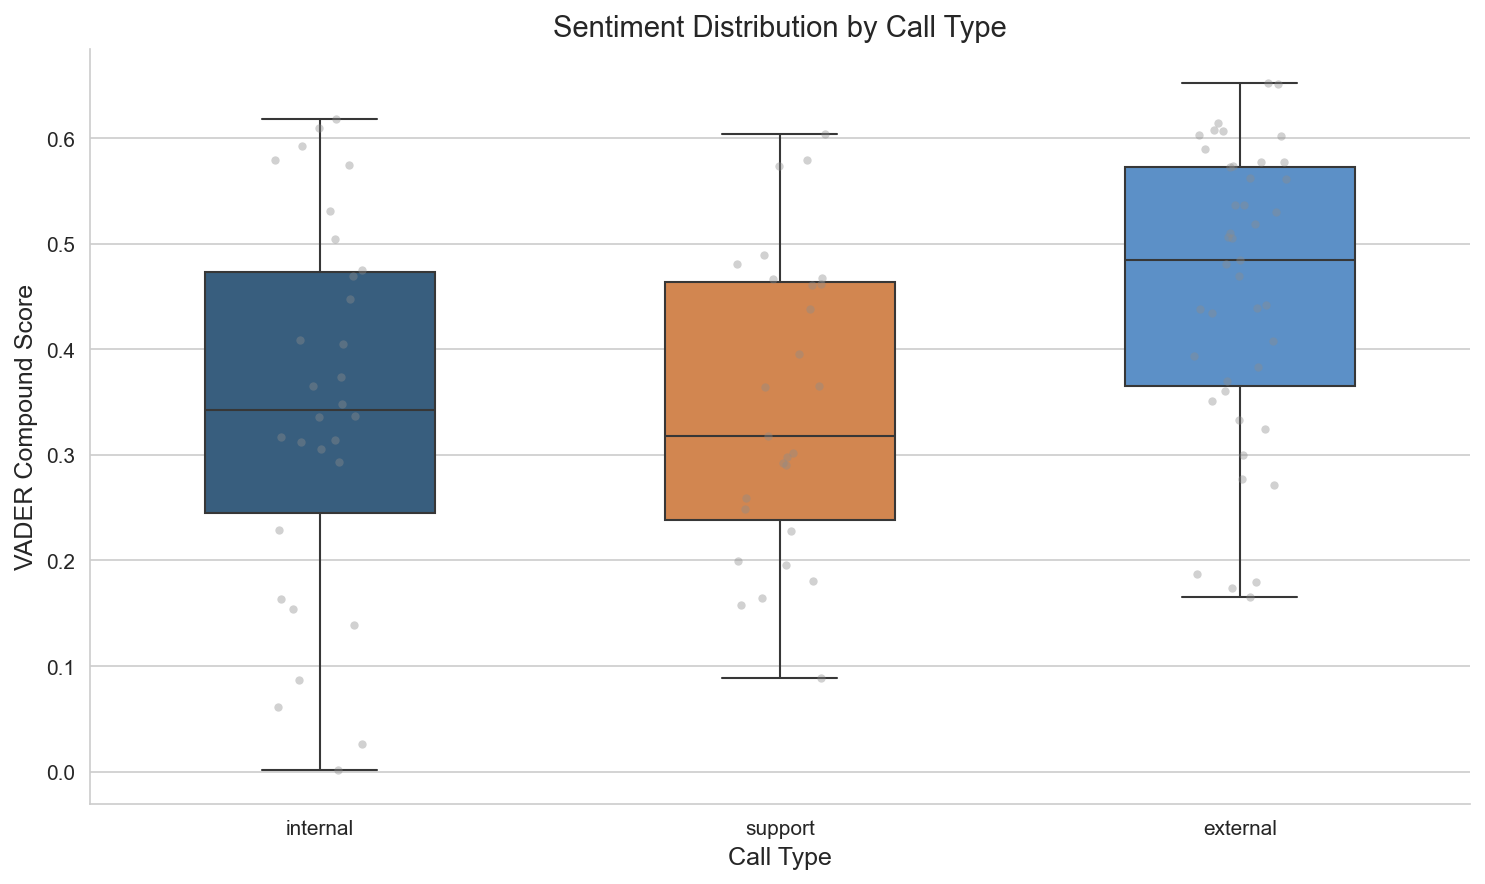

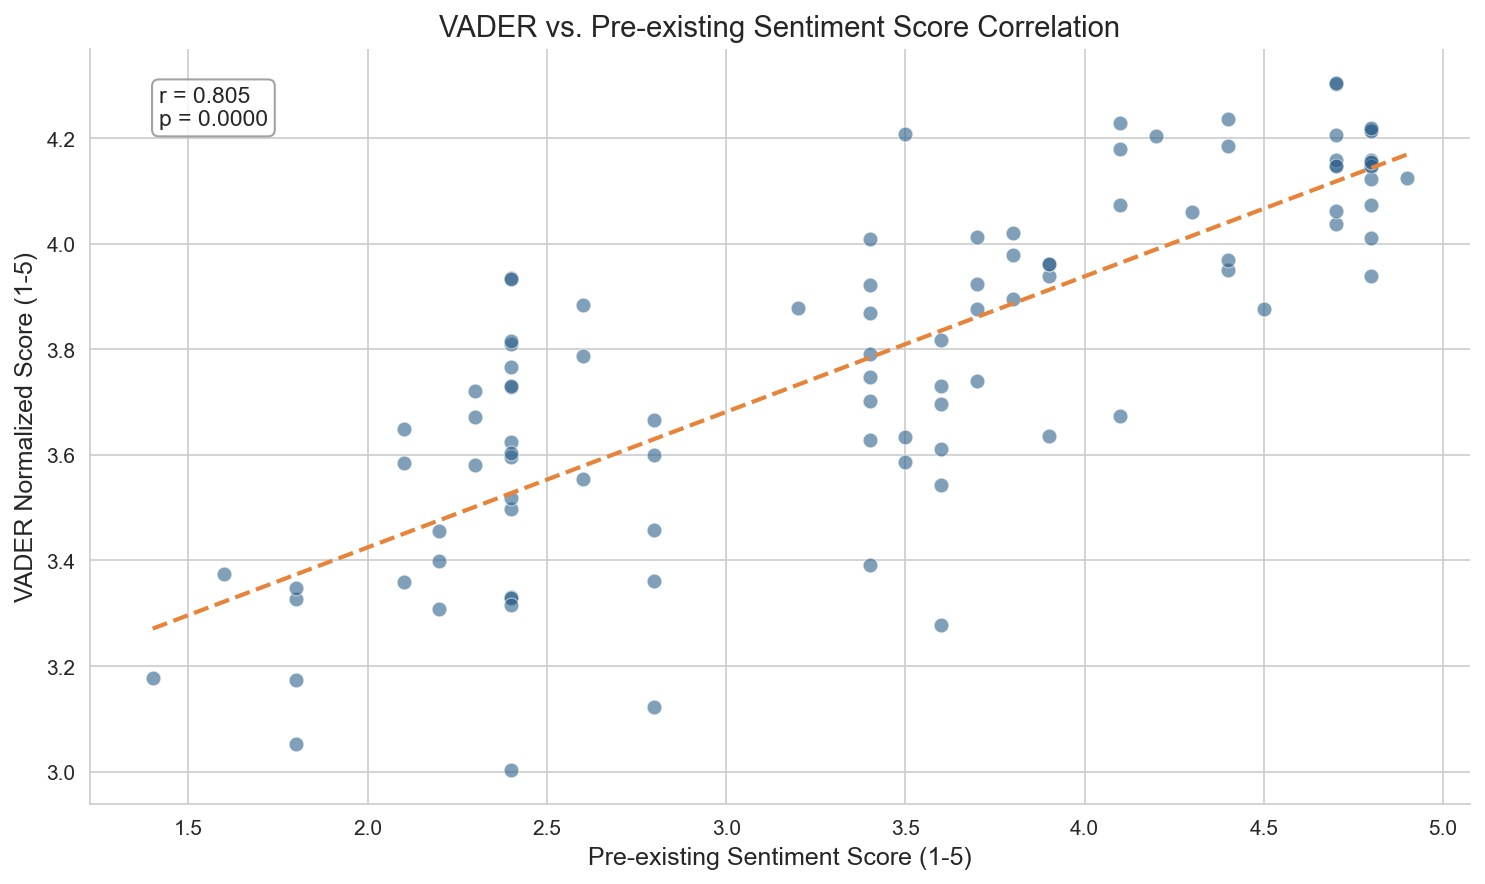

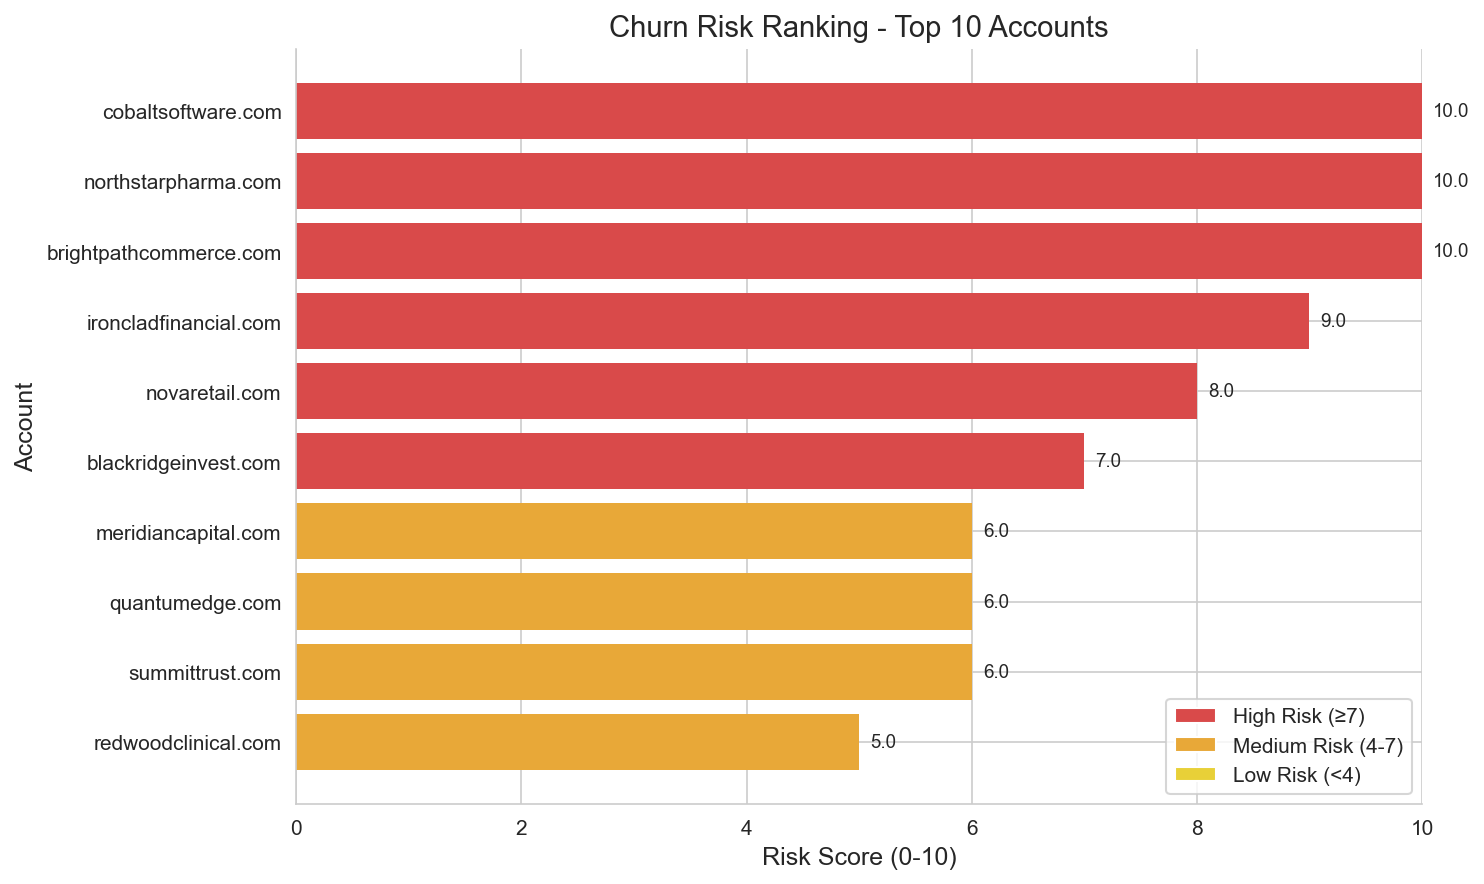

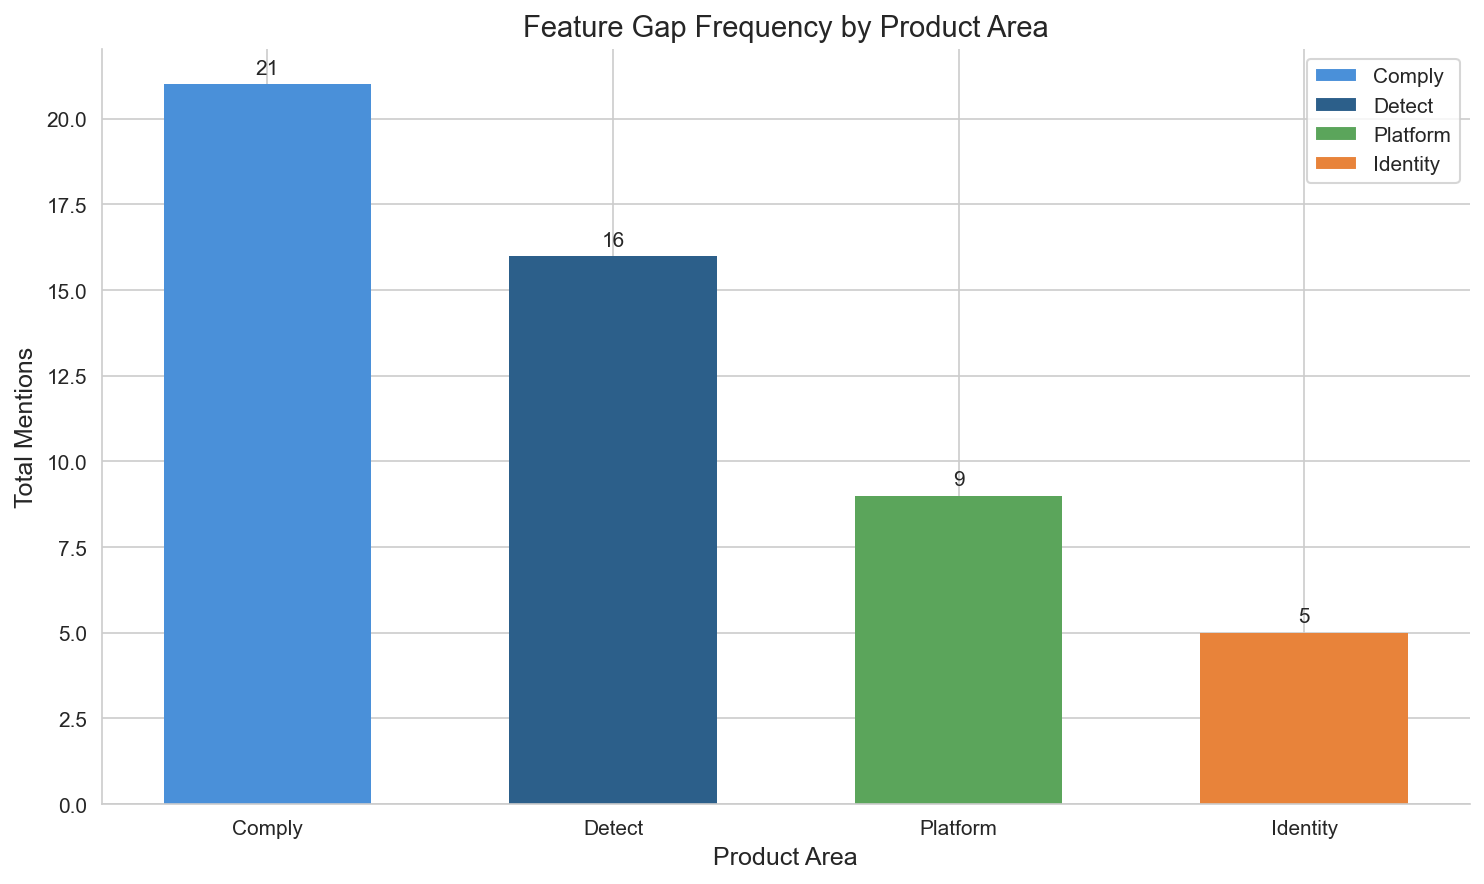

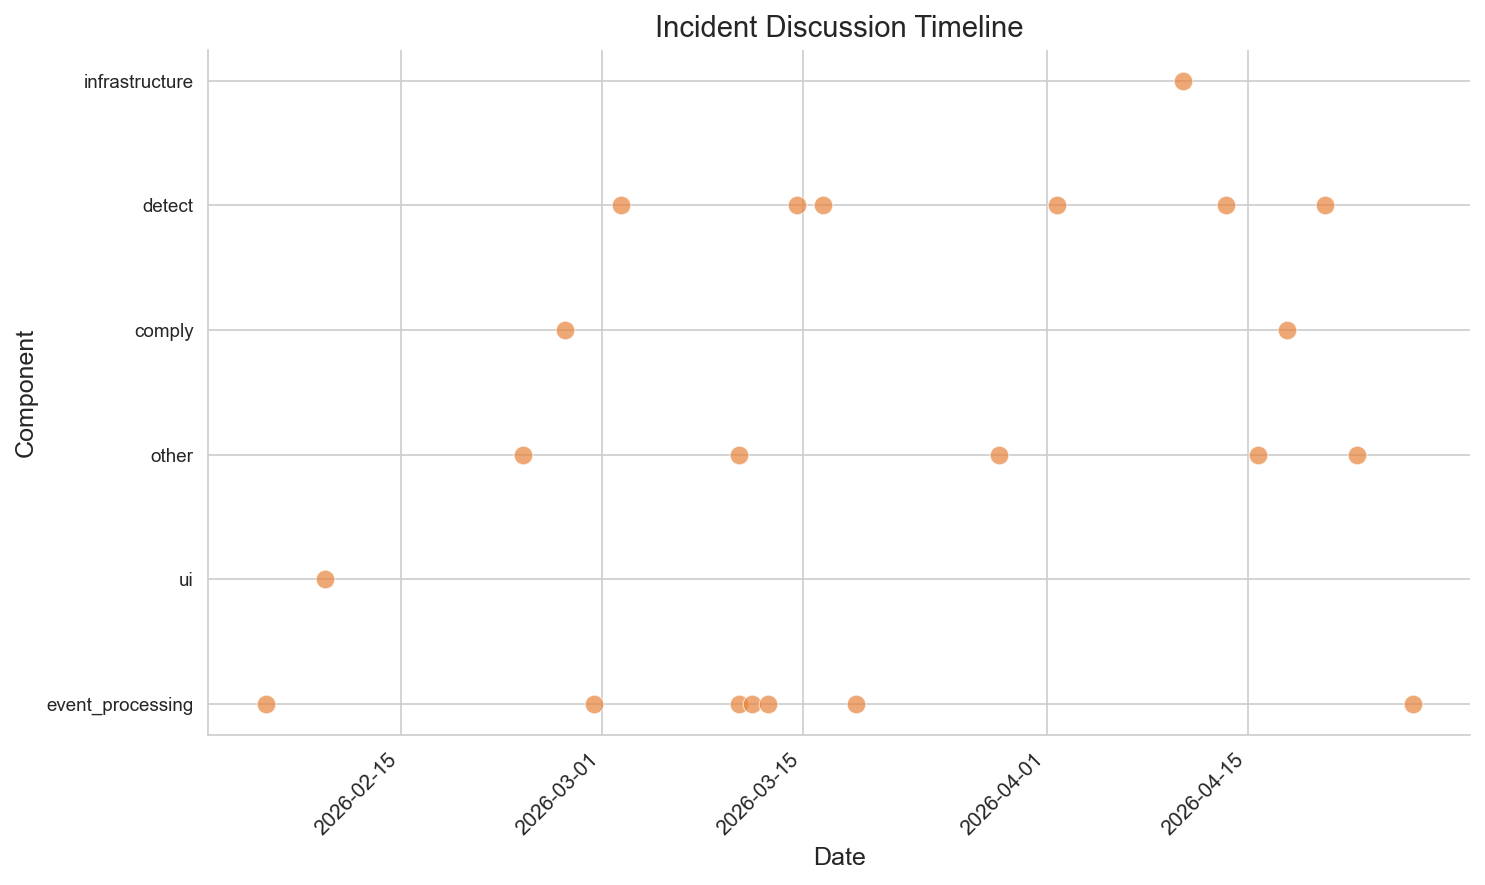

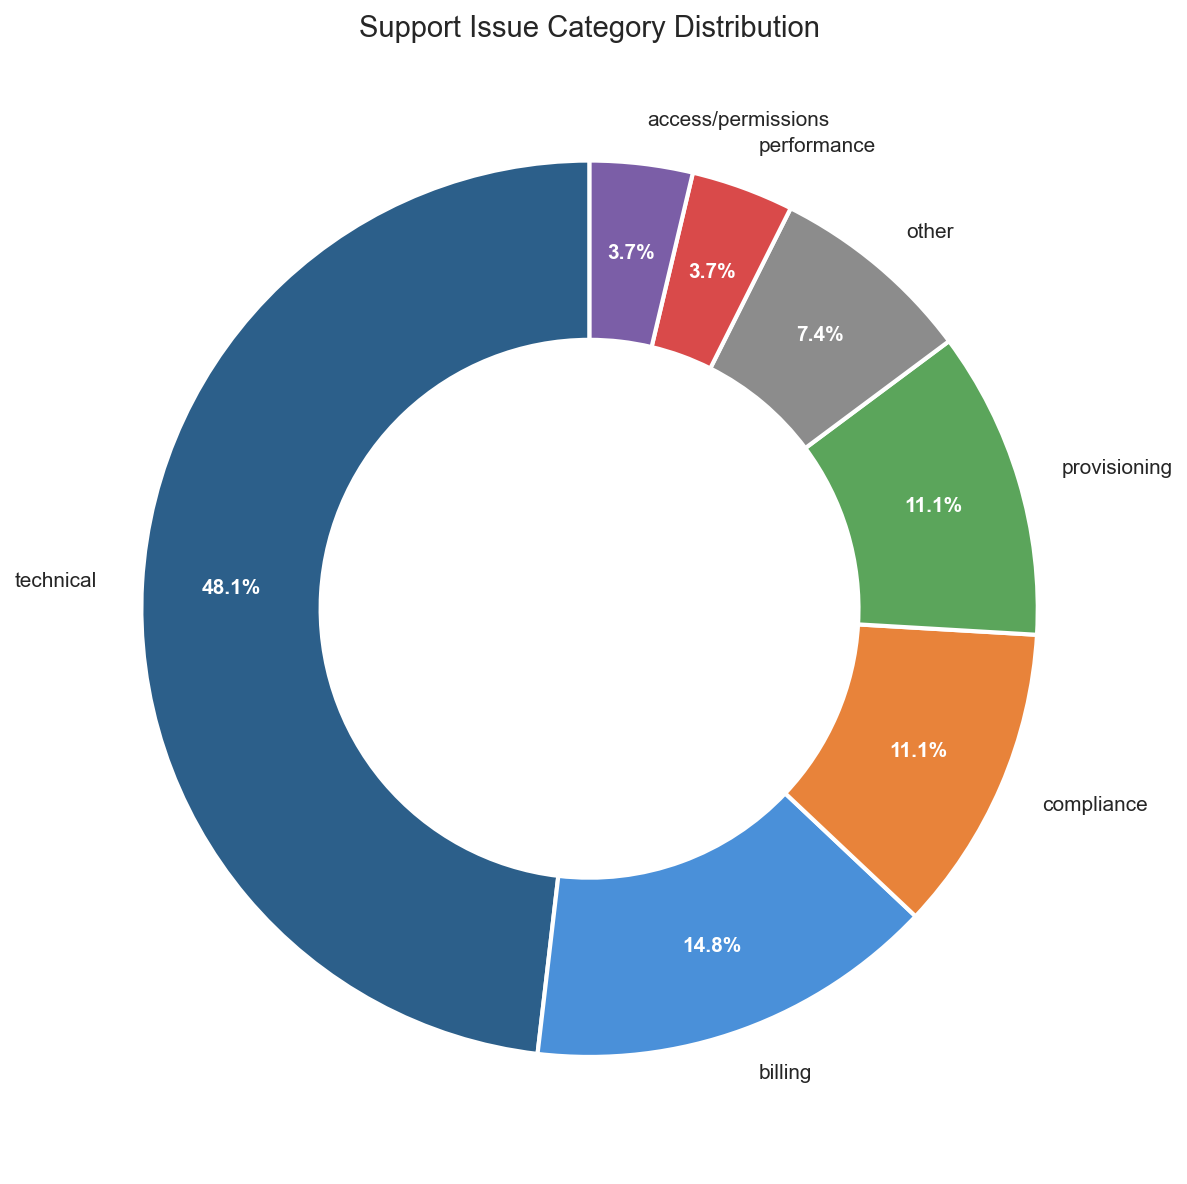

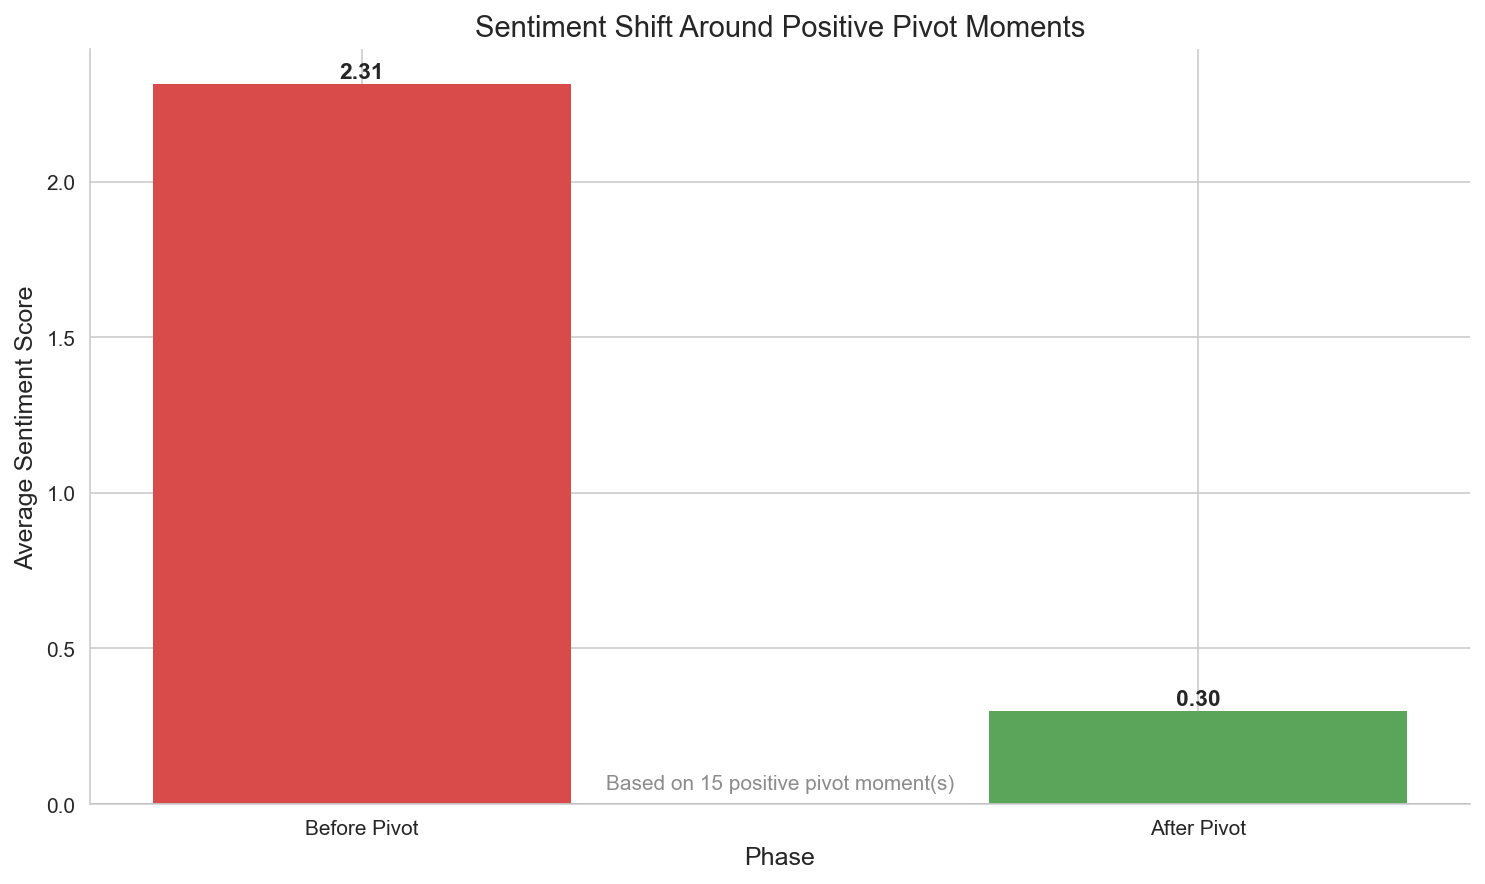

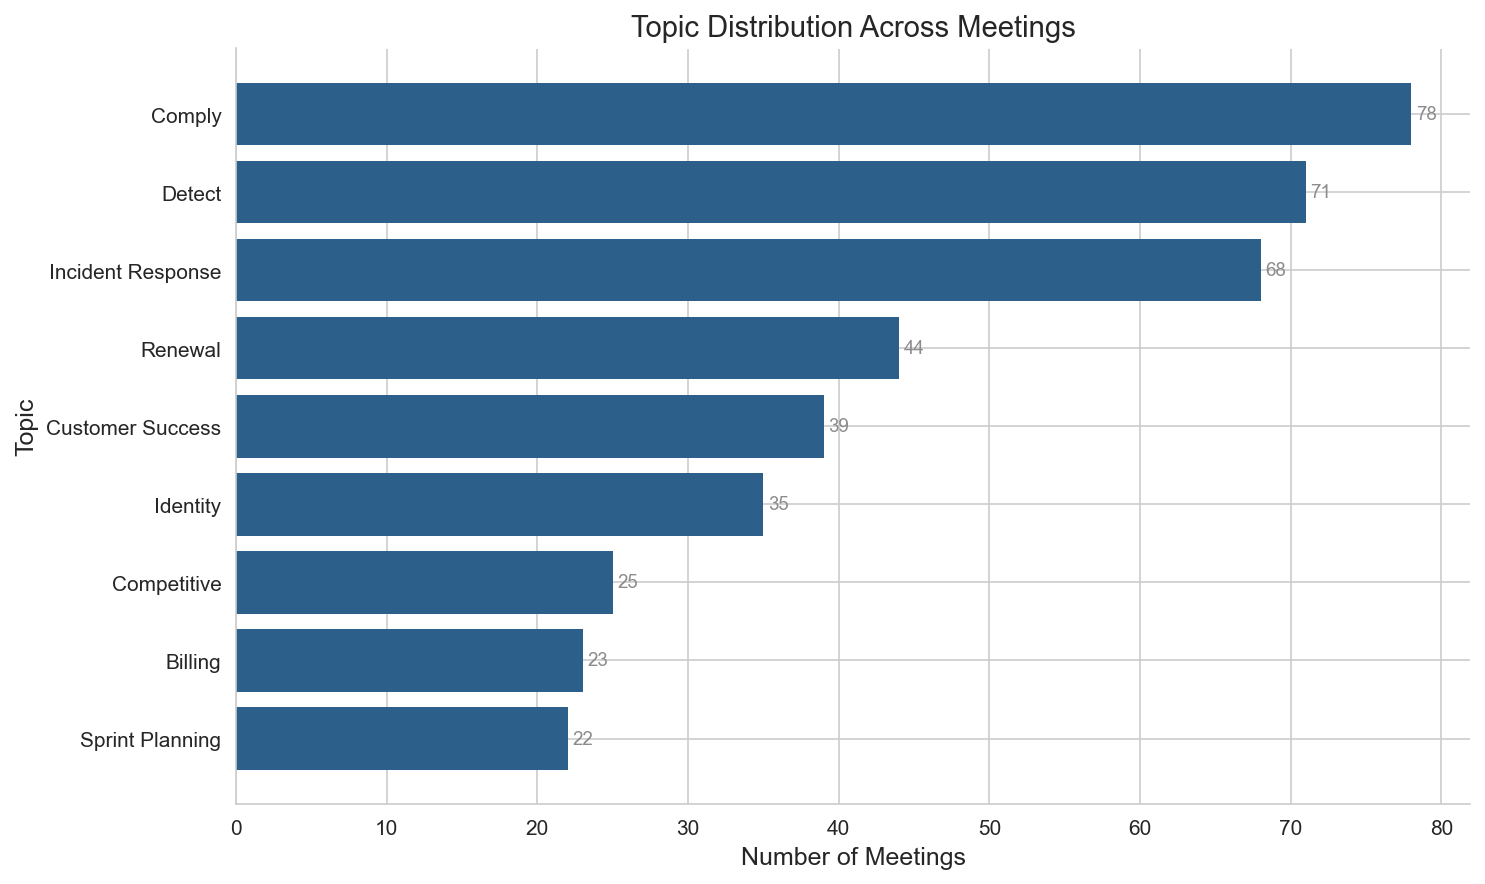

<Figure size 1500x900 with 0 Axes>

<Figure size 1500x900 with 0 Axes>

<Figure size 1500x900 with 0 Axes>

<Figure size 1500x900 with 0 Axes>

<Figure size 1500x900 with 0 Axes>

<Figure size 1500x900 with 0 Axes>

<Figure size 1500x900 with 0 Axes>

<Figure size 1500x900 with 0 Axes>


Exporting figures to output/figures/...
Export complete.


In [18]:
print("Generating visualizations...")

# Generate all charts
figures = create_all_visualizations(
    topic_results=topic_distribution,
    sentiment_results=sentiment_results,
    churn_results=churn_results,
    feature_gap_results=feature_gap_results,
    incident_results=incident_results,
    support_results=support_results,
)

print(f"Generated {len(figures)} charts:")
for name in figures.keys():
    print(f"  - {name}")

# Display all charts inline
for name, fig in figures.items():
    plt.figure(fig.number)
    plt.show()

# Export figures to output/figures/
print("\nExporting figures to output/figures/...")
export_figures(figures, output_dir='output/figures', fmt='png')
print("Export complete.")

## 11. Summary & Recommendations

### Key Findings

This analysis of ~100 AegisCloud meeting transcripts reveals actionable intelligence across four stakeholder groups:

In [20]:
print("="*60)
print("TRANSCRIPT INTELLIGENCE - KEY FINDINGS SUMMARY")
print("="*60)

print("\n1. CHURN RISK (For: Sales Managers)")
print("-"*40)
if not churn_results.empty:
    high_risk = churn_results[churn_results['risk_score'] >= 7]
    print(f"   High-risk accounts (score >= 7): {len(high_risk)}")
    print(f"   Total accounts assessed: {len(churn_results)}")
    if not high_risk.empty:
        print(f"   Top at-risk: {high_risk.iloc[0]['account_domain']}")
else:
    print("   No churn risk data available.")

print("\n2. FEATURE GAPS (For: Product Managers)")
print("-"*40)
if not feature_gap_results.empty:
    print(f"   Unique gaps identified: {len(feature_gap_results)}")
    print(f"   Total mentions: {feature_gap_results['mention_count'].sum()}")
    print(f"   Top gap: {feature_gap_results.iloc[0]['feature_description'][:80]}")
else:
    print("   No feature gaps identified.")

print("\n3. INCIDENT PATTERNS (For: Engineering Leads)")
print("-"*40)
if not systemic_df.empty:
    print(f"   Systemic issues: {len(systemic_df)}")
    for _, row in systemic_df.iterrows():
        print(f"   - {row['component']}: {row['issue_count']} issues across {row['meeting_count']} meetings")
else:
    print("   No systemic issues detected.")

print("\n4. SUPPORT ISSUES (For: Support Leaders)")
print("-"*40)
if not issue_categories.empty:
    print(f"   Issue categories: {len(issue_categories)}")
    print(f"   High-frustration cases: {len(frustration_cases)}")
    print(f"   Positive resolutions: {len(resolution_patterns)}")
else:
    print("   No support issue data available.")

print("\n" + "="*60)
print("RECOMMENDATIONS")
print("="*60)
print("""
1. Sales: Immediate outreach to high-risk accounts with tailored retention plans
2. Product: Incorporate top feature gaps into next quarter's roadmap review
3. Engineering: Root cause analysis on systemic issues; address team health signals
4. Support: Workflow optimization for top frustration categories; replicate resolution patterns
5. All: Continue monitoring sentiment trends; re-run pipeline monthly for tracking
""")

print("\nLIMITATIONS:")
print("- Sentiment analysis uses VADER (rule-based); may miss nuanced sarcasm")
print("- Topic categorization relies on keyword matching; novel topics may be missed")
print("- Churn risk is signal-based; does not incorporate CRM or contract data")
print("- Dataset is a point-in-time snapshot; longitudinal tracking recommended")

print("\nNEXT STEPS:")
print("- Integrate with CRM data for enriched churn risk scoring")
print("- Add LLM-based topic extraction for uncategorized meetings")
print("- Build automated alerting for new high-risk signals")
print("- Expand to larger corpus as more transcripts become available")

TRANSCRIPT INTELLIGENCE - KEY FINDINGS SUMMARY

1. CHURN RISK (For: Sales Managers)
----------------------------------------
   High-risk accounts (score >= 7): 6
   Total accounts assessed: 32
   Top at-risk: brightpathcommerce.com

2. FEATURE GAPS (For: Product Managers)
----------------------------------------
   Unique gaps identified: 51
   Total mentions: 51
   Top gap: Gregory requests proactive seat-count threshold alerts to avoid discovering over

3. INCIDENT PATTERNS (For: Engineering Leads)
----------------------------------------
   Systemic issues: 3
   - detect: 6 issues across 6 meetings
   - event_processing: 7 issues across 7 meetings
   - other: 5 issues across 5 meetings

4. SUPPORT ISSUES (For: Support Leaders)
----------------------------------------
   Issue categories: 7
   High-frustration cases: 16
   Positive resolutions: 15

RECOMMENDATIONS

1. Sales: Immediate outreach to high-risk accounts with tailored retention plans
2. Product: Incorporate top feature ga